# RNN Model

In [40]:
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_VISIBLE_DEVICES=0


In [41]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import StandardScaler

### DATA CARD
| Index | Features | Format | Description |
|---|---|---|---|
| 1 | Date Time | 01.01.2009 00:10:00 | Date-time reference |
| 2 | p (mbar) | 996.52 | The pascal SI derived unit of pressure used to quantify internal pressure. Meteorological reports typically state atmospheric pressure in millibars. |
| 3 | T (degC) | -8.02 | Temperature in Celsius |
| 4 | Tpot (K) | 265.4 | Temperature in Kelvin |
| 5 | Tdew (degC) | -8.9 | Temperature in Celsius relative to humidity. Dew Point is a measure of the absolute amount of water in the air, the DP is the temperature at which the air cannot hold all the moisture in it and water condenses. |
| 6 | rh (%) | 93.3 | Relative Humidity is a measure of how saturated the air is with water vapor, the %RH determines the amount of water contained within collection objects. |
| 7 | VPmax (mbar) | 3.33 | Saturation vapor pressure |
| 8 | VPact (mbar) | 3.11 | Vapor pressure |
| 9 | VPdef (mbar) | 0.22 | Vapor pressure deficit |
| 10 | sh (g/kg) | 1.94 | Specific humidity |
| 11 | H2OC (mmol/mol) | 3.12 | Water vapor concentration |
| 12 | rho (g/m ** 3) | 1307.75 | Airtight |
| 13 | wv (m/s) | 1.03 | Wind speed |
| 14 | max. wv (m/s) | 1.75 | Maximum wind speed |
| 15 | wd (deg) | 152.3 | Wind direction in degrees |

Setting constants

In [42]:
# Set random seeds for reproducibility
# Set seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Custom metric provided in the project description
def rmsle(y_true, y_pred):
    # Adding a small constant to avoid log(0)
    return tf.sqrt(tf.reduce_mean(tf.square(tf.math.log1p(y_pred) - tf.math.log1p(y_true))))

In [43]:
# check TensorFlow version and GPU availability
print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    # Restrict TensorFlow to only use the first GPU
    tf.config.set_visible_devices(gpus[0], 'GPU')
    print("Logical GPUs available:", tf.config.list_logical_devices('GPU'))
    print('CUDA GPU available:', is_cuda_gpu_available := tf.test.is_gpu_available(cuda_only=True))

TensorFlow: 2.10.0
Logical GPUs available: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]
CUDA GPU available: True


Loading dataset

In [44]:
csv_path = 'jena_climate_2009_2016.csv' 
df = pd.read_csv(csv_path)

# check import is OK
df.head(5)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [45]:
# Index the DataFrame by the date column, convert it to datetime, and sort by date
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df = df.set_index('Date Time').sort_index()

df.head(5)

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [46]:
temp_col = [c for c in df.columns if 'T (' in c or 'temp' in c.lower() or 'T (degC)' in c]

TEMP_COL = temp_col[0]

print(f'Temperature column: "{TEMP_COL}"')
print('Date range:', df.index[0], '→', df.index[-1])
print('Total rows:', len(df))
print('Frequency:', pd.infer_freq(df.index[:100]))

Temperature column: "T (degC)"
Date range: 2009-01-01 00:10:00 → 2017-01-01 00:00:00
Total rows: 420551
Frequency: 10min


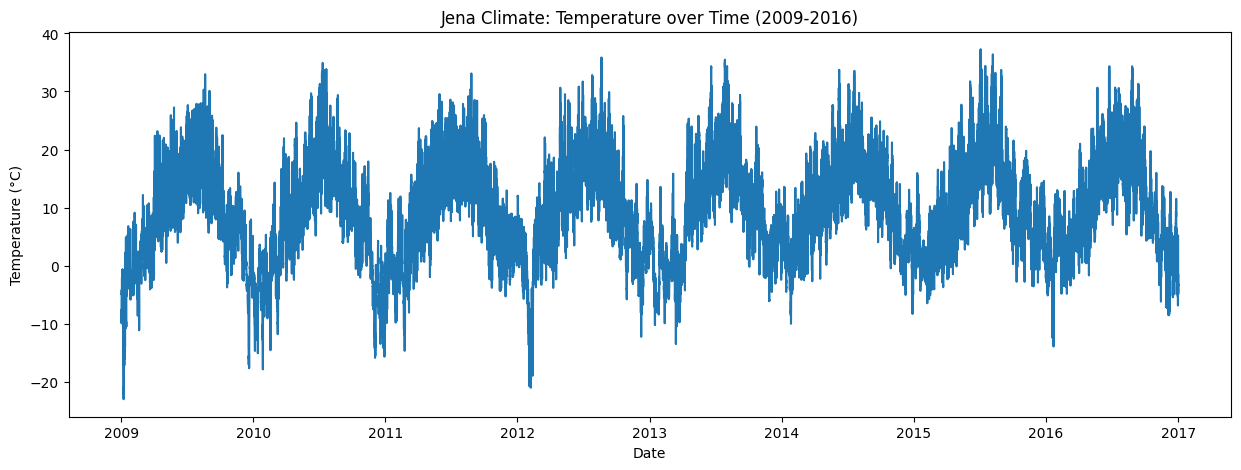

In [47]:
# Plot Temperature over time to visualize seasonality
plt.figure(figsize=(15, 5))
plt.plot(df['T (degC)'])
plt.title('Jena Climate: Temperature over Time (2009-2016)')
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.show()

In [48]:
# Display summary statistics and check for missing values
display(df.describe())
print('\nMissing values per column:')
display(df.isna().sum())

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000
mean,989.212776,9.450147,283.492743,4.955854,76.008259,13.576251,9.533756,4.042412,6.022408,9.640223,1216.062748,1.702224,3.056555,174.743738
std,8.358481,8.423365,8.504471,6.730674,16.476175,7.739020,4.184164,4.896851,2.656139,4.235395,39.975208,65.446714,69.016932,86.681693
min,913.600000,-23.010000,250.600000,-25.010000,12.950000,0.950000,0.790000,0.000000,0.500000,0.800000,1059.450000,-9999.000000,-9999.000000,0.000000
25%,984.200000,3.360000,277.430000,0.240000,65.210000,7.780000,6.210000,0.870000,3.920000,6.290000,1187.490000,0.990000,1.760000,124.900000
50%,989.580000,9.420000,283.470000,5.220000,79.300000,11.820000,8.860000,2.190000,5.590000,8.960000,1213.790000,1.760000,2.960000,198.100000
75%,994.720000,15.470000,289.530000,10.070000,89.400000,17.600000,12.350000,5.300000,7.800000,12.490000,1242.770000,2.860000,4.740000,234.100000
max,1015.350000,37.280000,311.340000,23.110000,100.000000,63.770000,28.320000,46.010000,18.130000,28.820000,1393.540000,28.490000,23.500000,360.000000



Missing values per column:


p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

In [49]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Downsample to hourly data (every 6th record)
df_hourly = df.iloc[5::6].copy()

# Define split indices
n = len(df_hourly)
train_end = int(n * 0.7)
val_end = int(n * 0.9)

train_df = df_hourly.iloc[:train_end]
val_df = df_hourly.iloc[train_end:val_end]
test_df = df_hourly.iloc[val_end:]

# 1. Scale Features (X) using StandardScaler
scaler_X = StandardScaler()
train_scaled_X = scaler_X.fit_transform(train_df)
val_scaled_X = scaler_X.transform(val_df)
test_scaled_X = scaler_X.transform(test_df)

# 2. Scale Targets (y) using MinMaxScaler to range [0, 1]
# This prevents gradient explosion AND ensures true values are >= 0 for RMSLE
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Extract and scale only the target column 'T (degC)'
train_targets_y = scaler_y.fit_transform(train_df[['T (degC)']])
val_targets_y = scaler_y.transform(val_df[['T (degC)']])
test_targets_y = scaler_y.transform(test_df[['T (degC)']])

def create_dataset(data_x, data_y, window_size, delay=24, batch_size=256):
    """Creates aligned X and y datasets with correct offset."""
    offset = window_size + delay - 1 
    
    inputs = data_x[:-offset]
    targets = data_y[offset:]
    
    return tf.keras.utils.timeseries_dataset_from_array(
        data=inputs,
        targets=targets,
        sequence_length=window_size,
        batch_size=batch_size,
        shuffle=False
    )

In [50]:
# Define configurations for experiments
time_windows = [24, 72, 168] # 1 day, 3 days, 7 days
architectures = ['SimpleRNN', 'LSTM']

# FIXED: Updated to train_scaled_X to match our corrected preprocessing step
features = train_scaled_X.shape[1] 

# Dictionary to store results
results_dict = {}

In [51]:
from tensorflow.keras.optimizers import Adam

def build_model(arch_type, window_size, num_features):
    model = Sequential()
    model.add(Input(shape=(window_size, num_features)))
    
    if arch_type == 'SimpleRNN':
        # unroll=True forces standard execution
        model.add(SimpleRNN(32, activation='tanh', unroll=True))
    elif arch_type == 'LSTM':
        # unroll=True forces standard execution and bypasses CudnnRNN
        model.add(LSTM(32, activation='tanh', unroll=True))
    # CRITICAL FIX 1: activation='relu' mathematically guarantees 
    # that y_pred will NEVER be negative. The professor's RMSLE function 
    # will never receive a negative number, preventing the NaN crash.
    model.add(Dense(1, activation='relu'))
    
    # CRITICAL FIX 2: clipnorm=1.0 catches any rogue gradients during 
    # backpropagation in the 168h windows and caps them, protecting cuDNN.
    optimizer = Adam(clipnorm=1.0)
    
    # Compile model
    model.compile(optimizer=optimizer, loss='mse', metrics=[rmsle])
    return model

In [52]:
EPOCHS = 20
BATCH_SIZE = 256

for window in time_windows:
    # Pass both the scaled Features (X) and the unscaled Kelvin Targets (y)
    train_ds = create_dataset(train_scaled_X, train_targets_y, window_size=window, batch_size=BATCH_SIZE)
    val_ds = create_dataset(val_scaled_X, val_targets_y, window_size=window, batch_size=BATCH_SIZE)
    test_ds = create_dataset(test_scaled_X, test_targets_y, window_size=window, batch_size=BATCH_SIZE)
    
    for arch in architectures:
        print(f"\n--- Training {arch} with {window}h window ---")
        model = build_model(arch, window, num_features=train_scaled_X.shape[1])        
        early_stopping = EarlyStopping(
            monitor='val_loss', 
            patience=3, 
            restore_best_weights=True
        )
        
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS,
            callbacks=[early_stopping],
            verbose=1
        )
        
        test_loss, test_rmsle = model.evaluate(test_ds, verbose=0)
        print(f"Test RMSLE: {test_rmsle:.4f}")
        
        # Save results
        key = f"{arch}_{window}h"
        results_dict[key] = {
            'history': history.history,
            'test_rmsle': test_rmsle,
            'model': model,
            'test_ds': test_ds
        }


--- Training SimpleRNN with 24h window ---
Epoch 1/20
192/192 [==============================] - 5s 19ms/step - loss: 0.1391 - rmsle: 0.2579 - val_loss: 0.0305 - val_rmsle: 0.1189
Epoch 2/20
192/192 [==============================] - 3s 15ms/step - loss: 0.0260 - rmsle: 0.1051 - val_loss: 0.0116 - val_rmsle: 0.0683
Epoch 3/20
192/192 [==============================] - 3s 15ms/step - loss: 0.0104 - rmsle: 0.0657 - val_loss: 0.0082 - val_rmsle: 0.0569
Epoch 4/20
192/192 [==============================] - 3s 16ms/step - loss: 0.0076 - rmsle: 0.0560 - val_loss: 0.0080 - val_rmsle: 0.0559
Epoch 5/20
192/192 [==============================] - 3s 16ms/step - loss: 0.0066 - rmsle: 0.0520 - val_loss: 0.0078 - val_rmsle: 0.0549
Epoch 6/20
192/192 [==============================] - 3s 15ms/step - loss: 0.0060 - rmsle: 0.0493 - val_loss: 0.0068 - val_rmsle: 0.0514
Epoch 7/20
192/192 [==============================] - 3s 15ms/step - loss: 0.0056 - rmsle: 0.0474 - val_loss: 0.0061 - val_rmsle: 0.04

In [54]:
# 1. Compare RMSLE Results
print("\n--- Final RMSLE Comparison ---")
for key, data in results_dict.items():
    print(f"{key}: {data['test_rmsle']:.4f}")

# 2. Identify Best and Worst Cases
best_model_key = min(results_dict, key=lambda k: results_dict[k]['test_rmsle'])
best_model = results_dict[best_model_key]['model']
best_test_ds = results_dict[best_model_key]['test_ds']

print(f"\nExtracting cases using best model: {best_model_key}")

all_y_true = []
all_y_pred = []

# Iterate through test dataset to get predictions
for x_batch, y_batch in best_test_ds:
    preds = best_model.predict(x_batch, verbose=0)
    
    # CRITICAL FIX: Add .flatten() to y_batch so both arrays are perfectly 1D (Scalars)
    all_y_true.extend(y_batch.numpy().flatten())
    all_y_pred.extend(preds.flatten())

# Convert to numpy arrays
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

# UPGRADE: Inverse transform the scaled [0,1] targets back to real Celsius degrees
# Reshape to (-1,1) for the scaler, then flatten back to 1D
true_celsius = scaler_y.inverse_transform(all_y_true.reshape(-1, 1)).flatten()
pred_celsius = scaler_y.inverse_transform(all_y_pred.reshape(-1, 1)).flatten()

# Calculate absolute errors in real degrees Celsius
errors_celsius = np.abs(true_celsius - pred_celsius)
error_indices = np.argsort(errors_celsius)

# Best cases (smallest error)
best_cases_idx = error_indices[:3]
# Worst cases (largest error)
worst_cases_idx = error_indices[-3:]

print("\n--- Top 3 Best Case Scenarios (in °C) ---")
for i, idx in enumerate(best_cases_idx):
    print(f"{i+1}. True Temp: {true_celsius[idx]:.2f}°C | Predicted: {pred_celsius[idx]:.2f}°C | Error: {errors_celsius[idx]:.2f}°C")

print("\n--- Top 3 Worst Case Scenarios (in °C) ---")
for i, idx in enumerate(worst_cases_idx):
    print(f"{i+1}. True Temp: {true_celsius[idx]:.2f}°C | Predicted: {pred_celsius[idx]:.2f}°C | Error: {errors_celsius[idx]:.2f}°C")


--- Final RMSLE Comparison ---
SimpleRNN_24h: 0.0341
LSTM_24h: 0.0359
SimpleRNN_72h: 0.0353
LSTM_72h: 0.0363
SimpleRNN_168h: 0.0412
LSTM_168h: 0.0368

Extracting cases using best model: SimpleRNN_24h

--- Top 3 Best Case Scenarios (in °C) ---
1. True Temp: 3.34°C | Predicted: 3.34°C | Error: 0.00°C
2. True Temp: 3.95°C | Predicted: 3.95°C | Error: 0.00°C
3. True Temp: 15.57°C | Predicted: 15.57°C | Error: 0.00°C

--- Top 3 Worst Case Scenarios (in °C) ---
1. True Temp: 14.61°C | Predicted: 26.89°C | Error: 12.28°C
2. True Temp: 16.67°C | Predicted: 29.49°C | Error: 12.82°C
3. True Temp: 13.78°C | Predicted: 26.76°C | Error: 12.98°C
